Used only past 24 h * 3 - Univariative LSTM

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor

In [2]:
# Load dataset
df = pd.read_csv("weather_15min_interpolated_load_domestic.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time (VERY IMPORTANT)
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,load_normalize,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,load_normalize.1
0,2025-06-10 00:00:00,25.600,94.00,100.0,0.0,6.4,0.201075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.837,peak load,0.9726
1,2025-06-10 00:15:00,25.675,94.25,100.0,0.0,6.4,0.331693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6044
2,2025-06-10 00:30:00,25.750,94.50,100.0,0.0,6.4,0.168803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8165
3,2025-06-10 00:45:00,25.825,94.75,100.0,0.0,6.4,0.200331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9690
4,2025-06-10 01:00:00,25.900,95.00,100.0,0.0,6.4,0.218110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0550


In [3]:
df.tail()

,timestamp,temperature_C,humidity_percent,cloud_cover_percent,solar_irradiance_Wm2,wind_speed_ms,load_normalize,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,load_normalize.1
2972,2025-07-10 23:00:00,27.50,88.00,99.00,0.0,13.60,0.324147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.5679
2973,2025-07-10 23:15:00,27.45,88.25,98.75,0.0,14.15,0.333223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6118
2974,2025-07-10 23:30:00,27.40,88.50,98.50,0.0,14.70,0.337544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6327
2975,2025-07-10 23:45:00,27.35,88.75,98.25,0.0,15.25,0.300682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4544
2976,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2977 entries, 0 to 2976
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             2976 non-null   datetime64[ns]
 1   temperature_C         2976 non-null   float64       
 2   humidity_percent      2976 non-null   float64       
 3   cloud_cover_percent   2976 non-null   float64       
 4   solar_irradiance_Wm2  2976 non-null   float64       
 5   wind_speed_ms         2976 non-null   float64       
 6   load_normalize        2976 non-null   float64       
 7   Unnamed: 7            0 non-null      float64       
 8   Unnamed: 8            0 non-null      float64       
 9   Unnamed: 9            0 non-null      float64       
 10  Unnamed: 10           0 non-null      float64       
 11  Unnamed: 11           0 non-null      float64       
 12  Unnamed: 12           0 non-null      float64       
 13  Unnamed: 13       

In [5]:
#  Interpolate missing values (linear for time series)
df = df.interpolate(method="linear")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2977 entries, 0 to 2976
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             2977 non-null   datetime64[ns]
 1   temperature_C         2977 non-null   float64       
 2   humidity_percent      2977 non-null   float64       
 3   cloud_cover_percent   2977 non-null   float64       
 4   solar_irradiance_Wm2  2977 non-null   float64       
 5   wind_speed_ms         2977 non-null   float64       
 6   load_normalize        2977 non-null   float64       
 7   Unnamed: 7            0 non-null      float64       
 8   Unnamed: 8            0 non-null      float64       
 9   Unnamed: 9            0 non-null      float64       
 10  Unnamed: 10           0 non-null      float64       
 11  Unnamed: 11           0 non-null      float64       
 12  Unnamed: 12           0 non-null      float64       
 13  Unnamed: 13       

C:\Users\HP\AppData\Local\Temp\ipykernel_24984\2707783040.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method="linear")


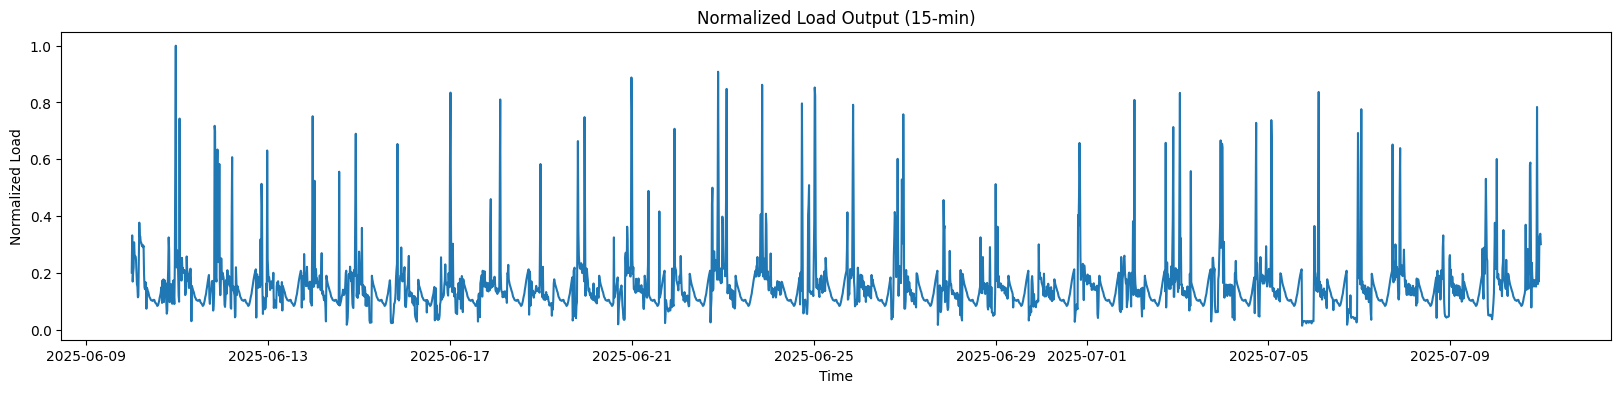

In [6]:
plt.figure(figsize=(20,4))
plt.plot(df["timestamp"], df["load_normalize"])
plt.title("Normalized Load Output (15-min)")
plt.xlabel("Time")
plt.ylabel("Normalized Load")
plt.show()

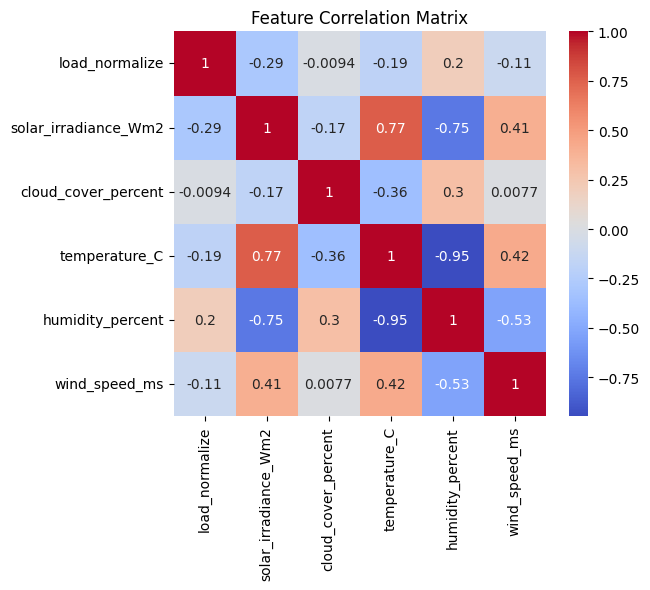

In [7]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[[
        "load_normalize",
        "solar_irradiance_Wm2",
        "cloud_cover_percent",
        "temperature_C",
        "humidity_percent",
        "wind_speed_ms"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()

In [8]:
# # Time-based features
# df["hour"] = df["timestamp"].dt.hour
# df["minute"] = df["timestamp"].dt.minute
# df["dayofyear"] = df["timestamp"].dt.dayofyear

# # Solar power lags
# df["solar_lag_1"] = df["solar_normalize"].shift(1)
# df["solar_lag_2"] = df["solar_normalize"].shift(2)
# df["solar_lag_4"] = df["solar_normalize"].shift(4)

# #Drop NaN
# df = df.dropna()

# Ramp rate (intra-hour variability)
#df["solar_ramp"] = df["solar_normalize"] - df["solar_lag_1"]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2977 entries, 0 to 2976
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             2977 non-null   datetime64[ns]
 1   temperature_C         2977 non-null   float64       
 2   humidity_percent      2977 non-null   float64       
 3   cloud_cover_percent   2977 non-null   float64       
 4   solar_irradiance_Wm2  2977 non-null   float64       
 5   wind_speed_ms         2977 non-null   float64       
 6   load_normalize        2977 non-null   float64       
 7   Unnamed: 7            0 non-null      float64       
 8   Unnamed: 8            0 non-null      float64       
 9   Unnamed: 9            0 non-null      float64       
 10  Unnamed: 10           0 non-null      float64       
 11  Unnamed: 11           0 non-null      float64       
 12  Unnamed: 12           0 non-null      float64       
 13  Unnamed: 13       

In [10]:
data = df[["load_normalize"]].values

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [12]:
import numpy as np

n_input = 96 * 3   # 3 days
n_output = 96      # 1 day

X = []
y = []

for i in range(0, len(data_scaled) - n_input - n_output, 96):
    X.append(data_scaled[i:i+n_input])
    y.append(data_scaled[i+n_input:i+n_input+n_output])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (28, 288, 1)
y shape: (28, 96, 1)


In [13]:
len(X), len(y)

(28, 28)

In [14]:
train_size = int(0.7 * len(X))
val_size   = int(0.15 * len(X))

X_train = X[:train_size]
X_val   = X[train_size:train_size+val_size]
X_test  = X[train_size+val_size:]

y_train = y[:train_size]
y_val   = y[train_size:train_size+val_size]
y_test  = y[train_size+val_size:]

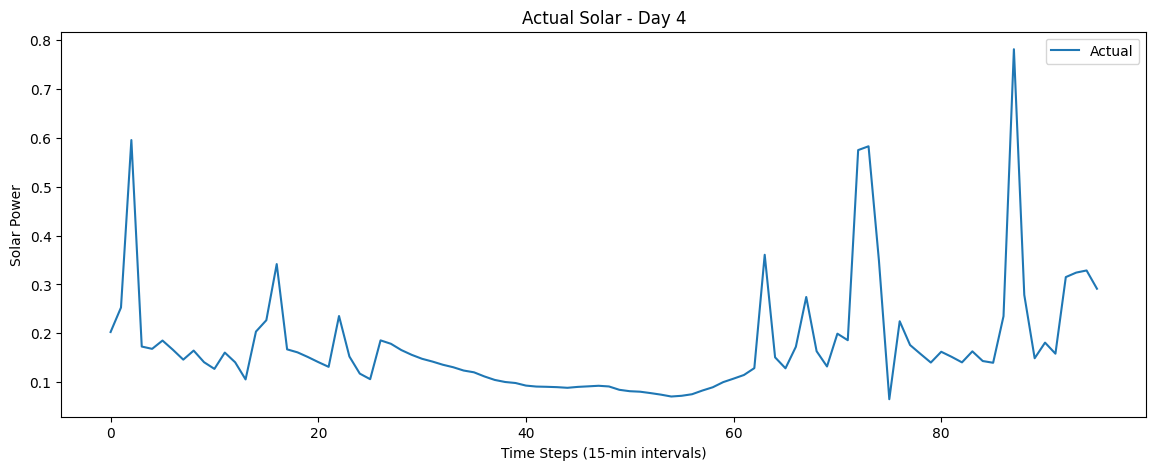

In [15]:
import matplotlib.pyplot as plt

day = 4  # change this to see different days

plt.figure(figsize=(14,5))

plt.plot(y_test[day], label="Actual")

plt.title(f"Actual Solar - Day {day}")
plt.xlabel("Time Steps (15-min intervals)")
plt.ylabel("Solar Power")
plt.legend()

plt.show()

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(288, 1)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(96, activation="relu"))

model.compile(
    optimizer='adam',
    loss='huber'
)

model.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 288, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 288, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │         6,240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,208 (477.38 KB)

 Trainable params: 122,208 (477.38 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train, y_train,
    epochs=10,# 300
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.0136 - val_loss: 0.0155
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - loss: 0.0129 - val_loss: 0.0146
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - loss: 0.0120 - val_loss: 0.0136
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - loss: 0.0110 - val_loss: 0.0124
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step - loss: 0.0099 - val_loss: 0.0114
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step - loss: 0.0091 - val_loss: 0.0110
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - loss: 0.0090 - val_loss: 0.0107
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - loss: 0.0089 - val_loss: 0.0101
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step - loss: 0.0080 - val_loss: 0.0096
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - loss: 0.0076 - val_loss: 0.0095


In [18]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step


In [19]:
# reshape for inverse
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# reshape back
y_pred_inv = y_pred_inv.reshape(y_pred.shape)
y_test_inv = y_test_inv.reshape(y_test.shape)

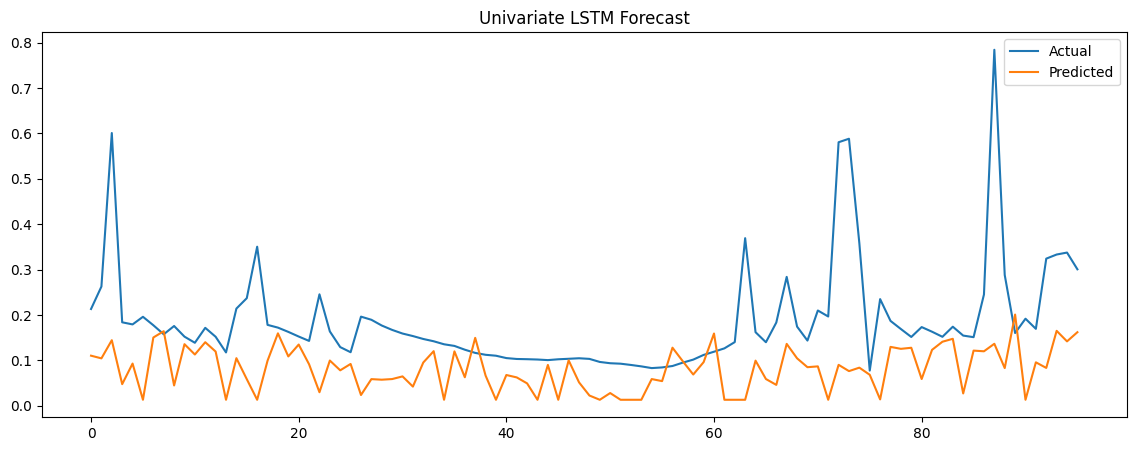

In [26]:
import matplotlib.pyplot as plt

day = 4

plt.figure(figsize=(14,5))

plt.plot(y_test_inv[day], label="Actual")
plt.plot(y_pred_inv[day], label="Predicted")

plt.legend()
plt.title("Univariate LSTM Forecast")
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error, r2_score

y_test_flat = y_test_inv.reshape(-1)
y_pred_flat = y_pred_inv.reshape(-1)

mae = mean_absolute_error(y_test_flat, y_pred_flat)
rmse = np.sqrt(np.mean((y_test_flat - y_pred_flat)**2))
r2 = r2_score(y_test_flat, y_pred_flat)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.08916174004782866
RMSE: 0.13058177365068055
R2: -0.6315067579598317
